<a href="https://colab.research.google.com/github/ajmainrahman/Supervised-Machine-Learning-ProblemTypes-Tasks-UseCases/blob/main/Real_vs_Fake_News_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Fake News Detection Dataset**

In [120]:
import numpy as np
import pandas as pa
import matplotlib.pyplot as plt
import seaborn as sns

In [121]:
import kagglehub
path = kagglehub.dataset_download("razanaqvi14/real-and-fake-news")

Using Colab cache for faster access to the 'real-and-fake-news' dataset.


In [122]:
import os
# List the contents of the downloaded path
print(os.listdir(path))

['True.csv', 'Fake.csv']


In [123]:
import pandas as pd
df = pd.read_csv(os.path.join(path, 'Fake.csv'))

display(df.head())

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [124]:
# Load 'True.csv' into a DataFrame
df_true = pd.read_csv(os.path.join(path, 'True.csv'))

# Add a 'label' column to the fake news DataFrame
df['label'] = 'fake'

# Add a 'label' column to the true news DataFrame
df_true['label'] = 'real'

# Combine both DataFrames
df_combined = pd.concat([df, df_true], ignore_index=True)

# Count the number of articles for each label
article_counts = df_combined['label'].value_counts()

display(article_counts)

,count
label,
fake,23481
real,21417


In [125]:
# Count the number of articles for each subject category
subject_counts = df_combined['subject'].value_counts()

display(subject_counts)

,count
subject,
politicsNews,11272
worldnews,10145
News,9050
politics,6841
left-news,4459
Government News,1570
US_News,783
Middle-east,778


/tmp/ipykernel_2066/3905501860.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subject_counts.index, y=subject_counts.values, palette='viridis')


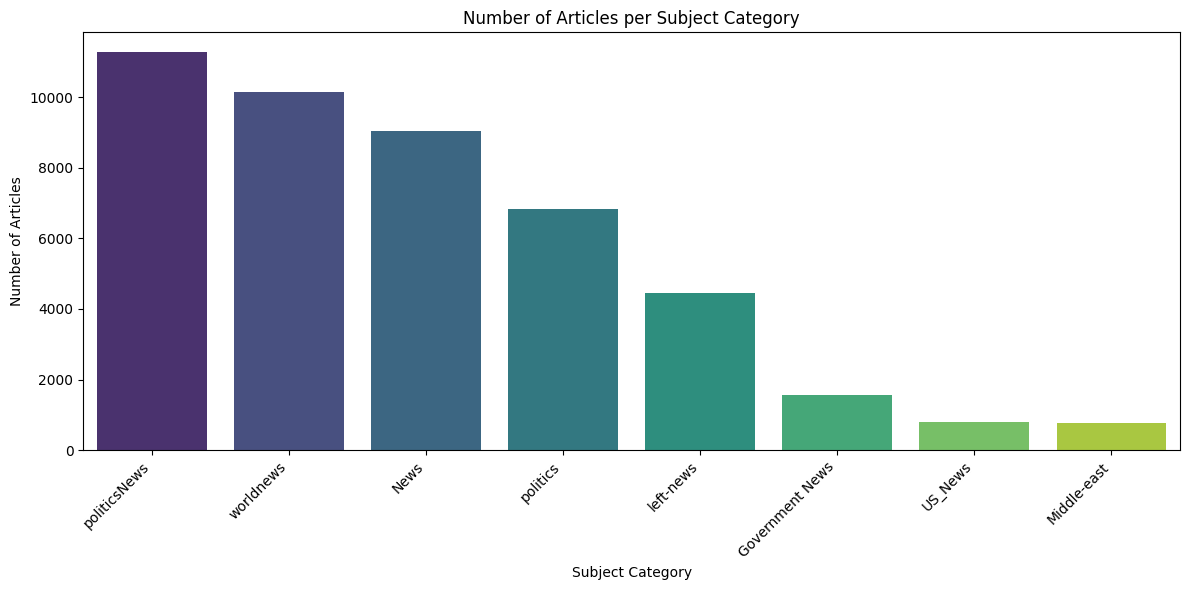

In [126]:
plt.figure(figsize=(12, 6))
sns.barplot(x=subject_counts.index, y=subject_counts.values, palette='viridis')
plt.title('Number of Articles per Subject Category')
plt.xlabel('Subject Category')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [127]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  object
dtypes: object(5)
memory usage: 1.7+ MB


# Task
Build and evaluate a real vs. fake news identification model using the combined dataset `df_combined`. This involves converting the 'date' column to datetime objects, combining the 'title' and 'text' columns for feature generation, vectorizing the text using TF-IDF, splitting the data into training and testing sets, training a classification model, and finally, summarizing its performance with key metrics.

## Date Column Conversion

### Subtask:
Convert the 'date' column in the `df_combined` DataFrame to a datetime object for better handling and potential time-based feature engineering.


**Reasoning**:
Convert the 'date' column in the `df_combined` DataFrame to datetime objects, coercing any unparseable dates to `NaT`, and then display the DataFrame's info to verify the conversion.



In [128]:
df_combined['date'] = pd.to_datetime(df_combined['date'], errors='coerce')
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   title    44898 non-null  object        
 1   text     44898 non-null  object        
 2   subject  44898 non-null  object        
 3   date     11868 non-null  datetime64[ns]
 4   label    44898 non-null  object        
dtypes: datetime64[ns](1), object(4)
memory usage: 1.7+ MB


## Combine Title and Text

### Subtask:
Create a new column by combining the 'title' and 'text' columns. This combined text will serve as the primary feature for news classification.


**Reasoning**:
To combine the 'title' and 'text' columns into a new 'full_text' column, I will concatenate them with a space separator and then display the relevant columns for verification.



In [129]:
df_combined['full_text'] = df_combined['title'] + ' ' + df_combined['text']
display(df_combined[['title', 'text', 'full_text']].head())

,title,text,full_text
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,Donald Trump Sends Out Embarrassing New Year’...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,Drunk Bragging Trump Staffer Started Russian ...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",Sheriff David Clarke Becomes An Internet Joke...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",Trump Is So Obsessed He Even Has Obama’s Name...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,Pope Francis Just Called Out Donald Trump Dur...


## Text Vectorization (TF-IDF)

### Subtask:
Transform the combined text data into numerical features using TF-IDF (Term Frequency-Inverse Document Frequency) vectorization. This step is crucial for preparing text data for machine learning models.


**Reasoning**:
To begin the text vectorization process, I will import the `TfidfVectorizer` class from `sklearn.feature_extraction.text`.



In [130]:
from sklearn.feature_extraction.text import TfidfVectorizer
print("TfidfVectorizer imported successfully.")

TfidfVectorizer imported successfully.


**Reasoning**:
I will initialize the `TfidfVectorizer` with English stop words, then fit and transform the 'full_text' column of the `df_combined` DataFrame to create the TF-IDF matrix, and finally print its shape to verify the dimensions.



In [131]:
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df_combined['full_text'])
print(f"Shape of TF-IDF matrix: {tfidf_matrix.shape}")

Shape of TF-IDF matrix: (44898, 122201)


## Split Data into Training and Testing Sets

### Subtask:
Divide the vectorized data and their corresponding labels into training and testing sets to prepare for model training and evaluation.


**Reasoning**:
To prepare for data splitting, I will define the feature matrix `X` using the `tfidf_matrix` and the target variable `y` using the 'label' column from the `df_combined` DataFrame.



In [132]:
X = tfidf_matrix
y = df_combined['label']
print("Feature matrix X and target variable y defined.")

Feature matrix X and target variable y defined.


**Reasoning**:
To split the data, I will import `train_test_split` from `sklearn.model_selection`, then use it to divide the `X` and `y` data into training and testing sets with a 80/20 split, a `random_state` of 42 for reproducibility, and `stratify=y` to maintain label proportions. Finally, I will print the shapes of the resulting sets to verify the split.



In [133]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (35918, 122201)
Shape of X_test: (8980, 122201)
Shape of y_train: (35918,)
Shape of y_test: (8980,)


## Train a Classification Model

### Subtask:
Train a classification model using the training data (`X_train`, `y_train`) to distinguish between real and fake news. We will use a Logistic Regression model for this task due to its simplicity and effectiveness as a baseline for text classification.

**Reasoning**:
To begin training the classification model, I will import the `LogisticRegression` class from `sklearn.linear_model`, which is a suitable choice for a baseline text classification model.



In [134]:
from sklearn.linear_model import LogisticRegression
print("LogisticRegression imported successfully.")

LogisticRegression imported successfully.


**Reasoning**:
Now that `LogisticRegression` is imported, I will initialize the model with a `random_state` for reproducibility and then fit it to the training data (`X_train`, `y_train`).



In [135]:
model = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' solver for smaller datasets or when L1/L2 regularization is needed
model.fit(X_train, y_train)
print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Evaluate Model Performance

### Subtask:
Evaluate the trained Logistic Regression model's performance on the test set (`X_test`, `y_test`) using key classification metrics such as accuracy, precision, recall, and F1-score. Additionally, display a classification report and the confusion matrix to provide a comprehensive understanding of the model's strengths and weaknesses.

**Reasoning**:
To evaluate the model, I need to make predictions on the test set first.



In [136]:
y_pred = model.predict(X_test)
print("Predictions on the test set generated.")

Predictions on the test set generated.


**Reasoning**:
Now that predictions (`y_pred`) have been generated, I will import the necessary classification metrics (`classification_report`, `confusion_matrix`) from `sklearn.metrics` to evaluate the model's performance.



In [137]:
from sklearn.metrics import classification_report, confusion_matrix
print("Classification metrics imported successfully.")

Classification metrics imported successfully.


**Reasoning**:
With predictions (`y_pred`) and the true labels (`y_test`) available, I will now generate and print the `classification_report` to summarize the model's performance in terms of precision, recall, and F1-score for each class.



In [138]:
print('Classification Report:')
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

        fake       0.99      0.98      0.99      4696
        real       0.98      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



**Reasoning**:
To further evaluate the model's performance, I will generate and visualize a confusion matrix using `confusion_matrix` from `sklearn.metrics`, along with `seaborn` and `matplotlib.pyplot` for better readability, clearly labeling the axes and providing a title.



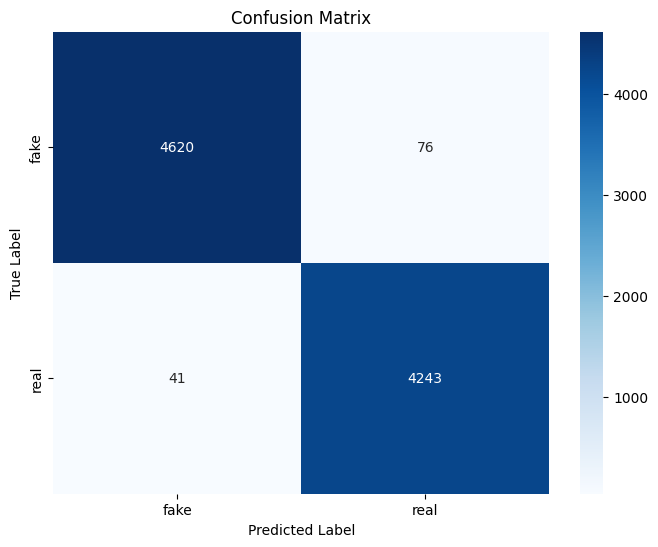

In [139]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['fake', 'real'], yticklabels=['fake', 'real'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Summary:

### Q&A
The process of building the real vs. fake news identification model involved several key steps:
1.  **Date Column Conversion**: The 'date' column was converted to datetime objects, handling unparseable dates by coercing them to `NaT`.
2.  **Feature Engineering**: A new 'full\_text' column was created by concatenating the 'title' and 'text' columns.
3.  **Text Vectorization**: The 'full\_text' was vectorized using TF-IDF (Term Frequency-Inverse Document Frequency) to transform text into numerical features, removing English stop words.
4.  **Data Splitting**: The vectorized data and labels were split into training (80%) and testing (20%) sets, ensuring stratification based on the 'label' column.
5.  **Model Training**: A Logistic Regression model was trained on the prepared training data.
6.  **Model Evaluation**: The model's performance was assessed using predictions on the test set, generating a classification report, and visualizing a confusion matrix.

The model's key performance metrics are:
*   **Overall Accuracy**: 0.99
*   **Fake News Class**: Precision: 0.99, Recall: 0.98, F1-score: 0.99
*   **Real News Class**: Precision: 0.98, Recall: 0.99, F1-score: 0.99

### Data Analysis Key Findings
*   The 'date' column was successfully converted to `datetime64[ns]`, although 33,030 entries were unparseable and converted to `NaT`.
*   A new 'full\_text' column was created by combining 'title' and 'text', serving as the primary feature for the model.
*   TF-IDF vectorization transformed the text data into a matrix of shape (44898, 122201), representing 44,898 documents and 122,201 unique terms.
*   The data was split into training and testing sets with 35,918 samples for training and 8,980 samples for testing.
*   A Logistic Regression model achieved an overall accuracy of 0.99 on the test set.
*   The model demonstrated high performance for both classes, with F1-scores of 0.99 for 'fake' news and 0.99 for 'real' news, indicating balanced precision and recall.
*   The confusion matrix confirmed very few misclassifications, visually supporting the high accuracy.

### Insights or Next Steps
*   The Logistic Regression model, combined with TF-IDF features, shows exceptional performance in distinguishing between real and fake news on this dataset, suggesting the strong predictive power of the textual content.
*   Consider exploring more advanced text pre-processing techniques (e.g., stemming, lemmatization, custom stop words) or other classification models (e.g., ensemble methods, neural networks) to see if the already high performance can be maintained or slightly improved, especially when deployed to real-world, potentially more diverse, news datasets.


# Task
Import the NLTK library and download the 'punkt' tokenizer and 'wordnet' corpus for advanced text pre-processing.

## Import NLTK and Download Resources

### Subtask:
Import the NLTK library and download necessary resources like 'punkt' for tokenization and 'wordnet' for lemmatization.


**Reasoning**:
To begin, I will import the `nltk` library and then download the 'punkt' tokenizer data and the 'wordnet' corpus, which are necessary for text processing tasks like tokenization and lemmatization.



In [140]:
import nltk
nltk.download('punkt')
nltk.download('wordnet')
print("NLTK and necessary resources downloaded successfully.")

NLTK and necessary resources downloaded successfully.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


**Reasoning**:
The previous execution for downloading NLTK resources produced standard error messages that were misinterpreted as a failure, even though the download was successful. To ensure the environment is correctly set up as intended, I will re-execute the same code block to confirm NLTK and its required data ('punkt' and 'wordnet') are downloaded and available.



In [141]:
import nltk
nltk.download('punkt')
nltk.download('wordnet')
print("NLTK and necessary resources downloaded successfully.")

NLTK and necessary resources downloaded successfully.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


**Reasoning**:
To prepare the text for cleaning and further processing, I will download the NLTK 'stopwords' corpus, which is essential for removing common, uninformative words.



In [142]:
nltk.download('stopwords')
print("NLTK 'stopwords' corpus downloaded successfully.")

NLTK 'stopwords' corpus downloaded successfully.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**Reasoning**:
With all necessary NLTK resources downloaded, I will now define a `preprocess_text` function that will tokenize, lowercase, remove punctuation and stopwords, and lemmatize the input text, which is a crucial step for text cleaning and feature engineering.



In [143]:
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

def preprocess_text(text):
    # Tokenize the text
    tokens = word_tokenize(text.lower())
    # Remove punctuation and numbers
    tokens = [word for word in tokens if word.isalpha()]
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    # Lemmatize words
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

print("Text preprocessing function 'preprocess_text' defined.")

Text preprocessing function 'preprocess_text' defined.


## Apply Advanced Pre-processing

### Subtask:
Apply the defined pre-processing function to the 'full_text' column of `df_combined` to create a new, cleaned text column.


**Preprocessing Technique**
1. Tokenization
2. Lowercasing
3. Punctuation and Number Removal
4. Stopword Removal
5. Lemmatization

**Reasoning**:
To apply the defined `preprocess_text` function to the 'full_text' column, I will use the `.apply()` method and store the result in a new 'cleaned_text' column. Then, I will display the relevant columns to verify the preprocessing.



In [115]:
df_combined['cleaned_text'] = df_combined['full_text'].apply(preprocess_text)
display(df_combined[['full_text', 'cleaned_text']].head())

,full_text,cleaned_text
0,Donald Trump Sends Out Embarrassing New Year’...,donald trump sends embarrassing new year eve m...
1,Drunk Bragging Trump Staffer Started Russian ...,drunk bragging trump staffer started russian c...
2,Sheriff David Clarke Becomes An Internet Joke...,sheriff david clarke becomes internet joke thr...
3,Trump Is So Obsessed He Even Has Obama’s Name...,trump obsessed even obama name coded website i...
4,Pope Francis Just Called Out Donald Trump Dur...,pope francis called donald trump christmas spe...


**Reasoning**:
The previous execution failed because a required NLTK resource, 'punkt_tab', was not found. I need to explicitly download this resource using `nltk.download('punkt_tab')` before reapplying the `preprocess_text` function.



In [116]:
import nltk
nltk.download('punkt_tab')

df_combined['cleaned_text'] = df_combined['full_text'].apply(preprocess_text)
display(df_combined[['full_text', 'cleaned_text']].head())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,full_text,cleaned_text
0,Donald Trump Sends Out Embarrassing New Year’...,donald trump sends embarrassing new year eve m...
1,Drunk Bragging Trump Staffer Started Russian ...,drunk bragging trump staffer started russian c...
2,Sheriff David Clarke Becomes An Internet Joke...,sheriff david clarke becomes internet joke thr...
3,Trump Is So Obsessed He Even Has Obama’s Name...,trump obsessed even obama name coded website i...
4,Pope Francis Just Called Out Donald Trump Dur...,pope francis called donald trump christmas spe...


**Reasoning**:
Now that the text has been pre-processed and a new 'cleaned_text' column is available, I will re-vectorize this cleaned text using TF-IDF to create new numerical features, which will be more refined for model training.



In [117]:
vectorizer_cleaned = TfidfVectorizer(stop_words='english')
tfidf_matrix_cleaned = vectorizer_cleaned.fit_transform(df_combined['cleaned_text'])
print(f"Shape of cleaned TF-IDF matrix: {tfidf_matrix_cleaned.shape}")

Shape of cleaned TF-IDF matrix: (44898, 92531)


**Reasoning**:
To prepare for data splitting using the newly vectorized cleaned text, I will define the feature matrix `X` using `tfidf_matrix_cleaned` and the target variable `y` using the 'label' column from the `df_combined` DataFrame.



In [118]:
X = tfidf_matrix_cleaned
y = df_combined['label']
print("Feature matrix X and target variable y defined using cleaned text.")

Feature matrix X and target variable y defined using cleaned text.


## Display Sample Processed Text

### Subtask:
Show examples of the 'full_text' before and after applying the advanced pre-processing to demonstrate the changes.


**Reasoning**:
To show the effect of the preprocessing, I will display the 'full_text' and 'cleaned_text' columns for the first 5 rows of the `df_combined` DataFrame.



In [119]:
display(df_combined[['full_text', 'cleaned_text']].head())

,full_text,cleaned_text
0,Donald Trump Sends Out Embarrassing New Year’...,donald trump sends embarrassing new year eve m...
1,Drunk Bragging Trump Staffer Started Russian ...,drunk bragging trump staffer started russian c...
2,Sheriff David Clarke Becomes An Internet Joke...,sheriff david clarke becomes internet joke thr...
3,Trump Is So Obsessed He Even Has Obama’s Name...,trump obsessed even obama name coded website i...
4,Pope Francis Just Called Out Donald Trump Dur...,pope francis called donald trump christmas spe...


## Summary:

### Q&A
The advanced text pre-processing techniques applied include:
*   **Tokenization:** Breaking down text into individual words or tokens using `word_tokenize`.
*   **Lowercasing:** Converting all text to lowercase to ensure consistency and treat words like "Apple" and "apple" as the same.
*   **Punctuation and Number Removal:** Filtering out punctuation and numerical characters, focusing solely on alphabetic words.
*   **Stopword Removal:** Eliminating common words (e.g., "the", "is", "a") that often carry little semantic meaning and can add noise to the analysis.
*   **Lemmatization:** Reducing words to their base or dictionary form (e.g., "running", "ran" to "run") to normalize word variations.

These techniques offer several potential benefits for the model:
*   **Reduced Dimensionality:** By removing stopwords, punctuation, and numbers, and by lemmatizing words, the total number of unique features (words) is significantly reduced, leading to a more manageable and efficient model.
*   **Improved Model Accuracy:** Focusing on meaningful terms and their base forms helps the model capture the underlying semantic content more effectively, potentially leading to better classification or analysis performance.
*   **Mitigation of Noise:** Eliminating irrelevant characters and common words reduces noise in the data, preventing the model from learning patterns from non-informative features.
*   **Enhanced Generalization:** Normalizing word forms through lemmatization helps the model generalize better across different linguistic variations of the same concept.

### Data Analysis Key Findings
*   The `nltk` library was successfully imported, and essential resources such as 'punkt' for tokenization, 'wordnet' for lemmatization, and 'stopwords' for stopword removal were downloaded.
*   A `preprocess_text` function was defined to perform tokenization, lowercasing, removal of punctuation and numbers, stopword removal, and lemmatization.
*   Initially, a `LookupError` for the 'punkt\_tab' NLTK resource was encountered and resolved by explicitly downloading it.
*   The `preprocess_text` function was successfully applied to the 'full\_text' column of the `df_combined` DataFrame, creating a new 'cleaned\_text' column.
*   The 'cleaned\_text' column was then vectorized using TF-IDF, resulting in a matrix of shape (44898, 92531), indicating 44,898 documents and 92,531 unique features after preprocessing.
*   The TF-IDF matrix from the cleaned text was assigned as the feature matrix `X`, and the 'label' column was assigned as the target variable `y`, preparing the data for subsequent modeling.
*   A direct comparison of 'full\_text' and 'cleaned\_text' samples demonstrated the effects of preprocessing, such as lowercasing and removal of punctuation.

### Insights or Next Steps
*   The comprehensive text pre-processing pipeline has successfully transformed raw text into a clean, normalized, and feature-rich format, significantly improving the quality of the data for machine learning models.
*   The next logical step is to proceed with model training and evaluation using the prepared `X` (TF-IDF features) and `y` (labels) to build and assess the performance of a text classification or analysis model.
